In [1]:
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy
import re
import joblib

import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.tokenize import sent_tokenize, word_tokenize

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sungj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sungj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sungj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sungj\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\sungj\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\sungj\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nl

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

In [12]:
def load_shuffle_csv(path):
    df = pd.read_csv(path)
    df = shuffle(df, random_state=42).reset_index(drop=True)
    return df

In [13]:
def clean_hos_df(df):
    df["text"] = df["text"].str.replace(r"[^a-zA-Z0-9$'\s ]", "", regex=True)
    df["text"] = df["text"].str.replace(r"<.*?>", "", regex=True)
    df.loc[df["Neutral"] == 1, "Neutral"] = 0
    df.loc[df["Negative"] == 1, "Negative"] = -1
    df.loc[df["Positive"] == 1 ,"Positive"] = 1
    df["sentiment"] = df["Negative"] + df["Positive"] + df["Neutral"]
    df = df.drop(columns=["Negative", "Positive", "Neutral"])

    index = df[df["text"].isna()].index
    df = df.drop(index=index).reset_index(drop=True)

    index = df[df["sentiment"].isna()].index
    df = df.drop(index=index).reset_index(drop=True)

    return df

In [14]:
def encode_sentiment(df):
    df.loc[df["sentiment"] == "Negative", "sentiment"] = '-1'
    df.loc[df["sentiment"] == "Neutral", "sentiment"] = '0'
    df.loc[df["sentiment"] == "Positive", "sentiment"] = '1'
    df["sentiment"] = df["sentiment"].astype('int').astype("category")
    return df

In [54]:
hos_df = load_shuffle_csv("hos_sentiment.csv")
hos_df = clean_hos_df(hos_df)
emotion_df = load_shuffle_csv("emotion_to_sentiment.csv")
social_media_df = load_shuffle_csv("social_media_sentiment.csv")

In [55]:
hos_df = hos_df.dropna().reset_index(drop=True)
emotion_df = emotion_df.dropna().reset_index(drop=True)
social_media_df = social_media_df.dropna().reset_index(drop=True)

In [56]:
emotion_df = encode_sentiment(emotion_df)
social_media_df = encode_sentiment(social_media_df)

In [57]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN

In [58]:
stop_words = set(stopwords.words("english"))
stop_words -= {"no", "nor", "not", "never",
    "none", "nothing", "nobody", "neither"}

def tokenize_text(df):
    df["text"] = df["text"].astype('string')

    processed_list = []
    bad_idx = []
    for idx, sentence in enumerate(df['text']):
        if sentence:
            words = word_tokenize(sentence)
            filtered_words = [word for word in words if word.lower() not in stop_words]

            tokens = [t for t in filtered_words if t.isalpha()]

            filtered_tokens = [t for t in tokens if t not in stop_words]

            tagged = nltk.pos_tag(filtered_tokens)

            lemmatized = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged]

            text = " ".join(lemmatized)
            if text.strip() == "":
                bad_idx.append(idx)
            else:
                processed_list.append(text)
        else:
            bad_idx.append(idx)
    df = df.drop(index=bad_idx).reset_index(drop=True)

    df.insert(1,"processed_text", processed_list)
    df = df.drop(columns=["text"])
    return df

In [59]:
hos_df = tokenize_text(hos_df)
emotion_df = tokenize_text(emotion_df)
social_media_df = tokenize_text(social_media_df)

In [60]:
df = pd.concat([hos_df, emotion_df, social_media_df], axis=0)
df.to_csv("processed_sentiment_data.csv", index=False)
X, y = df["processed_text"], df["sentiment"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [61]:
clean_df = pd.read_csv("processed_sentiment_data.csv")
print(clean_df.isna().sum())
df.isna().sum()

processed_text    0
sentiment         0
dtype: int64


processed_text    0
sentiment         0
dtype: int64

In [105]:
#Did a gridsearch on the Pipeline and got these values as the best.
#params = { 'logreg__C': [1, 2, 3], }
#https://zekehochberg.github.io/pipeline-and-gridsearch/ this was helpful to learn how to use GridSearchCV on a pipeline

In [28]:
#I ran it many times and did the gridsearch. These were the results that were best.
pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(
                ngram_range=(1, 3),
                stop_words=list(stop_words),
                min_df=.002,
                max_df=.9
            )),
            ('logreg', LogisticRegression(
                solver='lbfgs',
                C=.5,
                max_iter=300
            ))
        ])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

joblib.dump(pipeline, "tfidf_logreg_model.pkl")

0.8360746117798401
              precision    recall  f1-score   support

          -1       0.83      0.90      0.86      9376
           0       0.73      0.54      0.62      3891
           1       0.87      0.91      0.89      8499

    accuracy                           0.84     21766
   macro avg       0.81      0.78      0.79     21766
weighted avg       0.83      0.84      0.83     21766



['tfidf_logreg_model.pkl']

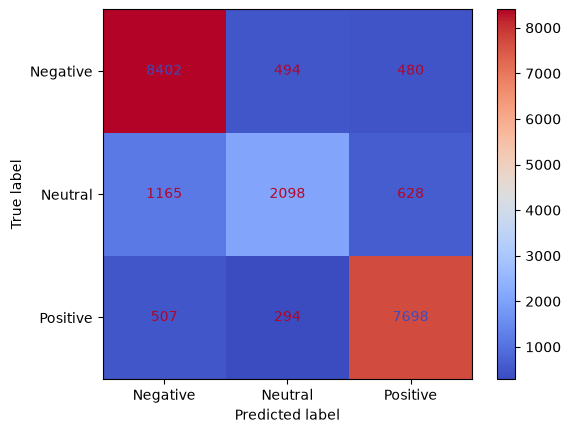

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Neutral", "Positive"])
cmd.plot(cmap="coolwarm")

In [30]:
model = joblib.load("tfidf_logreg_model.pkl")

In [31]:
def get_pred(pred, prob_arr):
    state = "Neutral"
    if pred == 1:
        state = "Positive"
    elif pred == -1:
        state =  "Negative"
    print(f"Prediction: {state} | Confidence: {(prob_arr[pred+1][0] * 100):.3f}%")

In [32]:
def predict(text):
    words = word_tokenize(text)
    filtered_words = [word for word in words if word.lower() not in stop_words]

    tokens = [t for t in filtered_words if t.isalpha()]

    filtered_tokens = [t for t in tokens if t not in stop_words]

    tagged = nltk.pos_tag(filtered_tokens)

    lemmatized = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged]
    proc_text = [" ".join(lemmatized)]

    pred, prob_arr = model.predict(proc_text), model.predict_proba(proc_text)[0]

    get_pred(pred, prob_arr)

In [33]:
predict("The house is in okay condition, but it could be better")

Prediction: Neutral | Confidence: 57.850%
